In [81]:
import pandas as pd 
import numpy as np
import re
import nltk
from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet


nltk.download('punkt')
nltk.download('punkt_tab')  # 🔥 NEW (important)
nltk.download('averaged_perceptron_tagger_eng')  # 🔥 NEW
nltk.download('wordnet')
nltk.download('omw-1.4')



import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to C:\Users\ABDULLAH AL
[nltk_data]     MASUM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\ABDULLAH AL
[nltk_data]     MASUM\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\ABDULLAH AL
[nltk_data]     MASUM\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to C:\Users\ABDULLAH AL
[nltk_data]     MASUM\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ABDULLAH AL
[nltk_data]     MASUM\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [82]:
# pip install bs4


In [83]:
#pip install pandas
#!pip install nltk

In [84]:
df = pd.read_csv("questions.csv")

In [85]:
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0


In [86]:
df= df.sample(50000, random_state= 2)

In [87]:
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate
339499,339499,665522,665523,Why was Cyrus Mistry removed as the Chairman o...,Why did the Tata Sons sacked Cyrus Mistry?,1
289521,289521,568878,568879,By what age would you think a man should be ma...,When my wrist is extended I feel a shock and b...,0
4665,4665,9325,9326,How would an arbitrageur seek to capitalize gi...,How would an arbitrageur seek to capitalize gi...,0


In [88]:
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)

def preprocess(q):
    q = str(q).lower().strip()
    
    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')
    
    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')
    
    # Replacing some numbers with string equivalents (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')
    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)
    
    # Decontracting words
    contractions = { 
        "ain't": "am not",
        "aren't": "are not",
        "can't": "can not",
        "can't've": "can not have",
        "'cause": "because",
        "could've": "could have",
        "couldn't": "could not",
        "couldn't've": "could not have",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hadn't've": "had not have",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he would",
        "he'd've": "he would have",
        "he'll": "he will",
        "he'll've": "he will have",
        "he's": "he is",
        "how'd": "how did",
        "how'd'y": "how do you",
        "how'll": "how will",
        "how's": "how is",
        "i'd": "i would",
        "i'd've": "i would have",
        "i'll": "i will",
        "i'll've": "i will have",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it'd": "it would",
        "it'd've": "it would have",
        "it'll": "it will",
        "it'll've": "it will have",
        "it's": "it is",
        "let's": "let us",
        "ma'am": "madam",
        "mayn't": "may not",
        "might've": "might have",
        "mightn't": "might not",
        "mightn't've": "might not have",
        "must've": "must have",
        "mustn't": "must not",
        "mustn't've": "must not have",
        "needn't": "need not",
        "needn't've": "need not have",
        "o'clock": "of the clock",
        "oughtn't": "ought not",
        "oughtn't've": "ought not have",
        "shan't": "shall not",
        "sha'n't": "shall not",
        "shan't've": "shall not have",
        "she'd": "she would",
        "she'd've": "she would have",
        "she'll": "she will",
        "she'll've": "she will have",
        "she's": "she is",
        "should've": "should have",
        "shouldn't": "should not",
        "shouldn't've": "should not have",
        "so've": "so have",
        "so's": "so as",
        "that'd": "that would",
        "that'd've": "that would have",
        "that's": "that is",
        "there'd": "there would",
        "there'd've": "there would have",
        "there's": "there is",
        "they'd": "they would",
        "they'd've": "they would have",
        "they'll": "they will",
        "they'll've": "they will have",
        "they're": "they are",
        "they've": "they have",
        "to've": "to have",
        "wasn't": "was not",
        "we'd": "we would",
        "we'd've": "we would have",
        "we'll": "we will",
        "we'll've": "we will have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what'll": "what will",
        "what'll've": "what will have",
        "what're": "what are",
        "what's": "what is",
        "what've": "what have",
        "when's": "when is",
        "when've": "when have",
        "where'd": "where did",
        "where's": "where is",
        "where've": "where have",
        "who'll": "who will",
        "who'll've": "who will have",
        "who's": "who is",
        "who've": "who have",
        "why's": "why is",
        "why've": "why have",
        "will've": "will have",
        "won't": "will not",
        "won't've": "will not have",
        "would've": "would have",
        "wouldn't": "would not",
        "wouldn't've": "would not have",
        "y'all": "you all",
        "y'all'd": "you all would",
        "y'all'd've": "you all would have",
        "y'all're": "you all are",
        "y'all've": "you all have",
        "you'd": "you would",
        "you'd've": "you would have",
        "you'll": "you will",
        "you'll've": "you will have",
        "you're": "you are",
        "you've": "you have"
    }
    
    q_decontracted = []
    for word in q.split():
        if word in contractions:
            word = contractions[word]
        q_decontracted.append(word)
    q = ' '.join(q_decontracted)
    
    q = q.replace("'ve", " have")
    q = q.replace("n't", " not")
    q = q.replace("'re", " are")
    q = q.replace("'ll", " will")
    
    # Removing HTML tags
    q = BeautifulSoup(q, "html.parser").get_text()
    
    # Tokenize text
    words = word_tokenize(q)
    
    # Stemming
    stemmer = PorterStemmer()
    stemmed_words = [stemmer.stem(word) for word in words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in stemmed_words]
    
    # Join words back to string
    q = ' '.join(lemmatized_words)
    
    # Remove punctuations
    pattern = re.compile(r'\W')
    q = re.sub(pattern, ' ', q).strip()
    
    return q


In [89]:
preprocess("I've already! wasn't <b>done</b>?")

'i have alreadi   wa not do'

In [90]:
df["question1"] = df["question1"].apply(preprocess)
df["question2"] = df["question2"].apply(preprocess)

In [91]:
df

,id,qid1,qid2,question1,question2,is_duplicate
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0
54203,54203,107861,107862,whi do quora mark my question a incomplet,whi doe quora detect my question a an incomple...,1
132566,132566,262554,91499,what be it like work with pivot lab a a client,what be it like to work at pivot lab,0
...,...,...,...,...,...,...
17006,17006,33939,33940,how should i start my prepar for gre,how do i start off for gre,1
368660,368660,721494,721495,what be a few reason that a complet non racist...,how ha sino u relationship evolv and how would...,0
346180,346180,678369,678370,what be import thing for peopl intend to major...,what be import thing for peopl intend to major...,0
120896,120896,239582,239583,what be econom cost,what be the econom cost of corrupt,0


In [92]:
df["q1_len"] = df["question1"].str.len()
df["q2_len"] = df["question2"].str.len()

In [93]:
df["q1_num_word"] = df["question1"].apply(lambda row: len(row.split(" ")))
df["q2_num_word"] = df["question2"].apply(lambda row: len(row.split(" ")))

In [94]:
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59


In [95]:
def common_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))    
    return len(w1 & w2)

In [96]:
df["word_common"] = df.apply(common_words, axis= 1)
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,word_common
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8,6
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24,3
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59,19


In [97]:
def total_word(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return(len(w1)+ len(w2))

In [98]:
df["word_total"] = df.apply(total_word, axis= 1)
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,word_common,word_total
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8,6,19
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24,3,31
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59,19,38


In [99]:
df["word_share"]= round(df["word_common"]/ df["word_total"],2)
df.head(3)

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,word_common,word_total,word_share
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8,6,19,0.32
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24,3,31,0.10
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59,19,38,0.50


In [100]:
# Advanced Features
from nltk.corpus import stopwords

def fetch_token_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [101]:
token_features= df.apply(fetch_token_features, axis=1)
df["cwc_min"] = list(map(lambda x:x[0],token_features))
df["cwc_max"] = list(map(lambda x:x[1],token_features))
df["csc_min"] = list(map(lambda x:x[2],token_features))
df["csc_max"] = list(map(lambda x:x[3],token_features))

df["ctc_min"] = list(map(lambda x:x[4],token_features))
df["ctc_max"] = list(map(lambda x:x[5],token_features))
df["last_word_eq"] = list(map(lambda x:x[6],token_features))
df["first_word_eq"] = list(map(lambda x:x[7],token_features))

In [102]:
# pip install distance

In [103]:
import distance

def fetch_length_features(row):
    
    q1 = row['question1']
    q2 = row['question2']
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [104]:

length_features = df.apply(fetch_length_features, axis=1)

df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
df['mean_len'] = list(map(lambda x: x[1], length_features))
df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [105]:
# !pip install fuzzywuzzy

In [106]:
from fuzzywuzzy import fuzz
def fetch_fuzzy_features(row):
    q1= row["question1"]
    q2 = row["question2"]
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [107]:

fuzzy_features = df.apply(fetch_fuzzy_features, axis=1)

df["fuzz_ratio"] = list(map(lambda x: x[0], fuzzy_features))
df["fuzz_partial_ratio"] = list(map(lambda x: x[1], fuzzy_features))
df["fuzz_token_sort_ratio"] = list(map(lambda x: x[2], fuzzy_features))
df["fuzz_token_set_ratio"] = list(map(lambda x: x[3], fuzzy_features))

In [108]:
print(df.shape)
df.head()

(50000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8,...,0.545450,0.0,1.0,3.0,9.5,0.324324,39,47,67,88
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24,...,0.136363,0.0,0.0,11.0,16.5,0.120000,26,49,38,39
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59,...,0.749997,1.0,1.0,0.0,24.0,0.992188,100,100,100,100
54203,54203,107861,107862,whi do quora mark my question a incomplet,whi doe quora detect my question a an incomple...,1,41,55,8,10,...,0.599994,0.0,1.0,2.0,9.0,0.357143,77,76,75,89
132566,132566,262554,91499,what be it like work with pivot lab a a client,what be it like to work at pivot lab,0,46,36,11,9,...,0.636358,0.0,1.0,2.0,10.0,0.432432,78,89,78,91


# Visualization

In [109]:
# pip install plotly

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

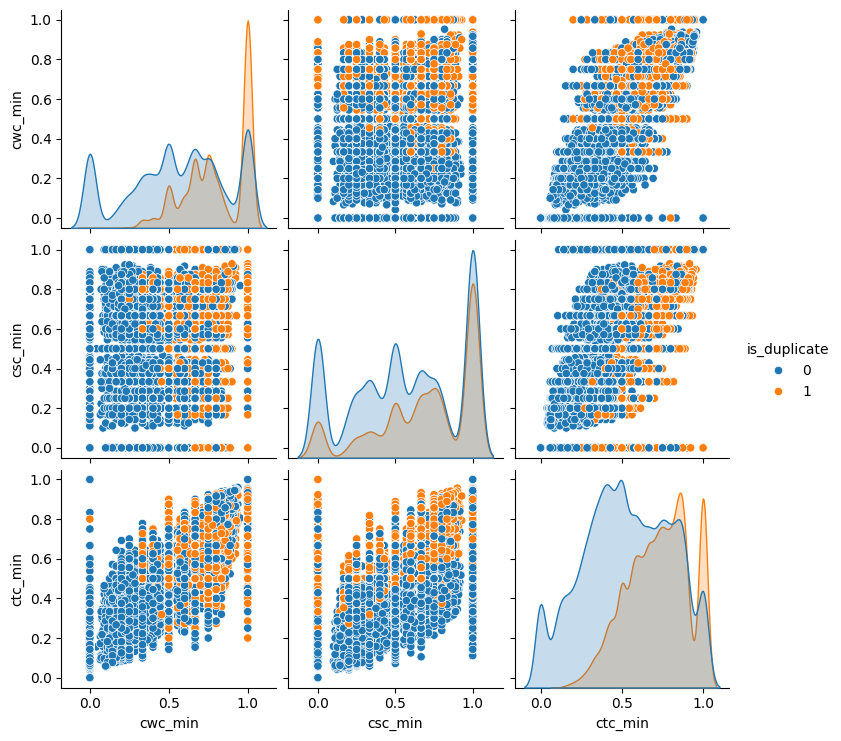

In [111]:
sns.pairplot(df[["cwc_min", "csc_min", "ctc_min","is_duplicate"]], hue="is_duplicate")

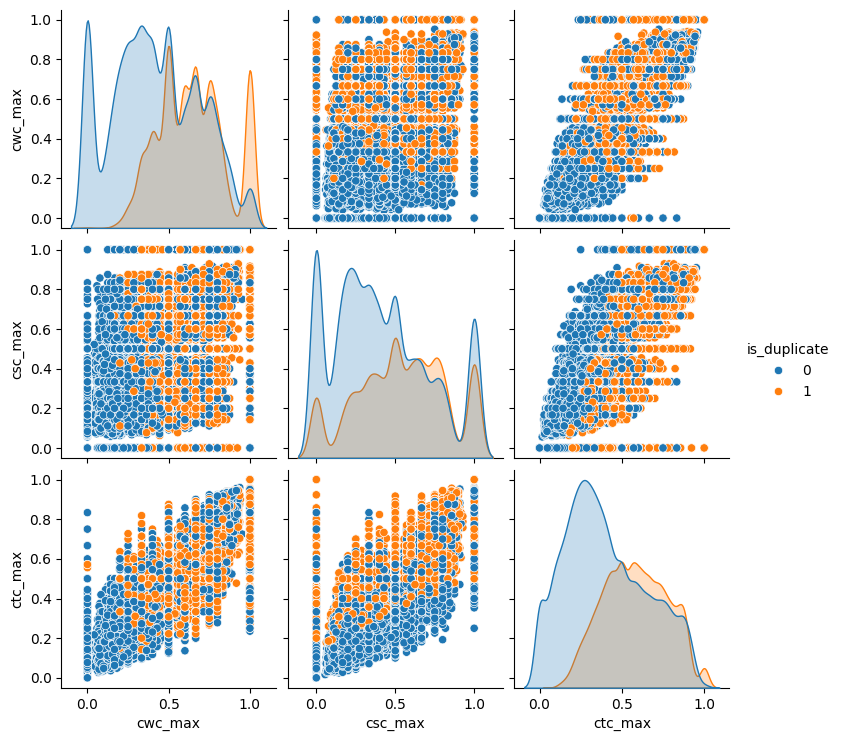

In [112]:
sns.pairplot(df[["cwc_max", "csc_max", "ctc_max","is_duplicate"]], hue="is_duplicate")

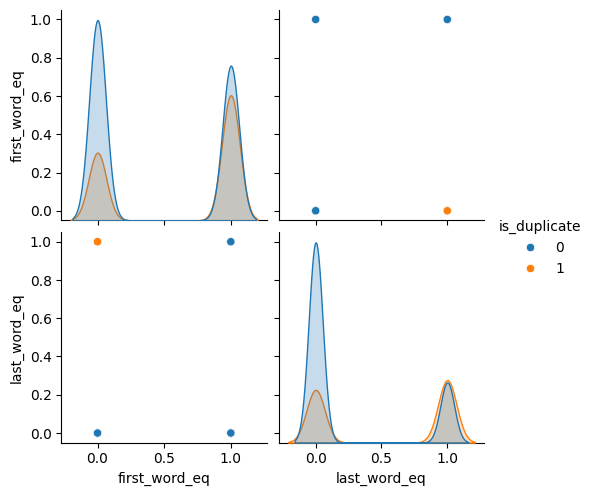

In [113]:
sns.pairplot(df[["first_word_eq", "last_word_eq", "is_duplicate"]], hue="is_duplicate")

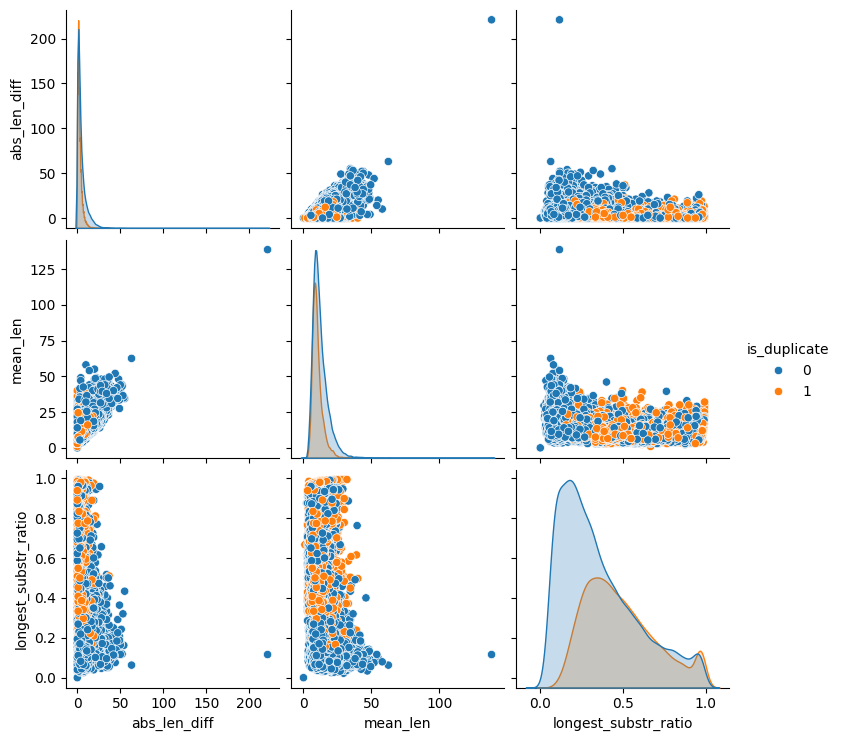

In [114]:
sns.pairplot(df[["abs_len_diff", "mean_len", "longest_substr_ratio","is_duplicate"]], hue="is_duplicate")

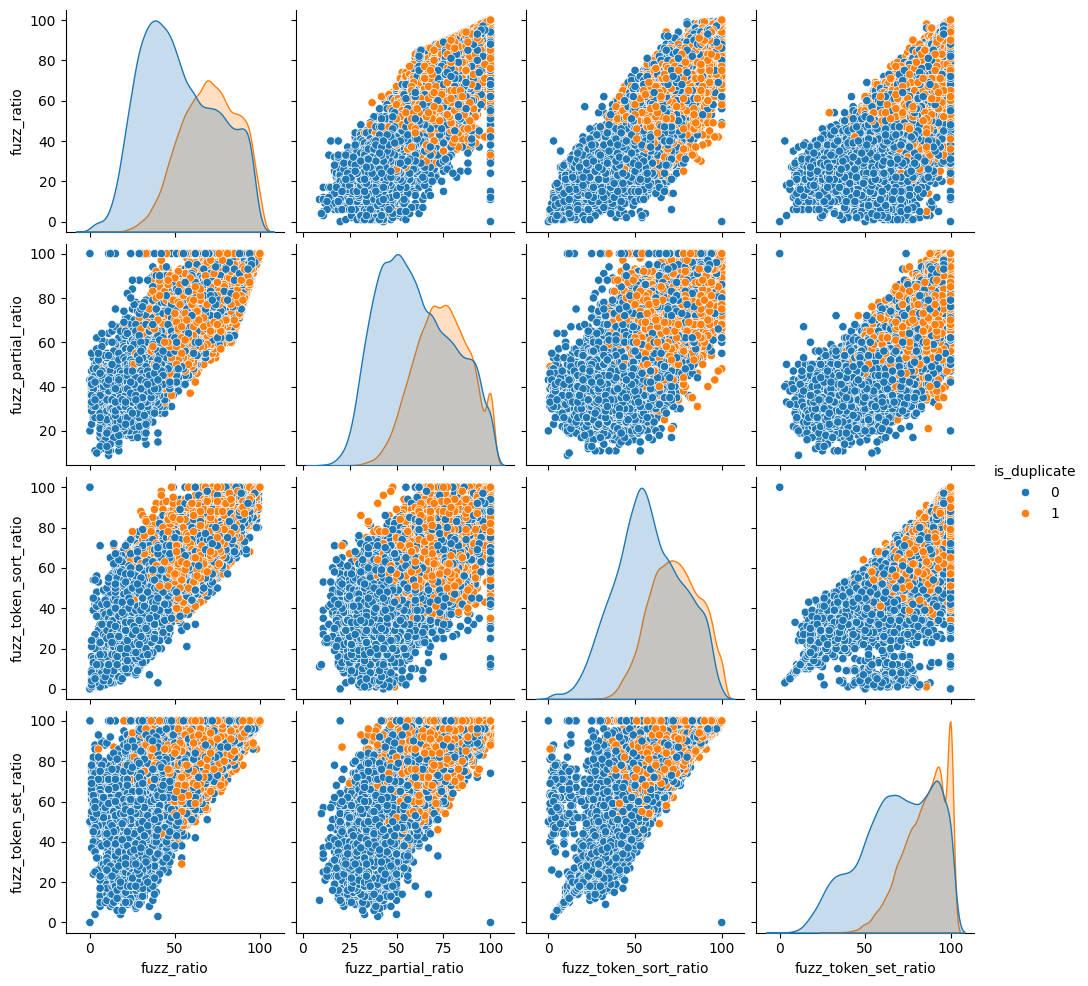

In [115]:
sns.pairplot(df[["fuzz_ratio", "fuzz_partial_ratio", "fuzz_token_sort_ratio","fuzz_token_set_ratio","is_duplicate"]], hue="is_duplicate")

In [116]:
from sklearn.preprocessing import MinMaxScaler

In [117]:
x = df[["cwc_min", "csc_min", "ctc_min", "cwc_max", "csc_max", "ctc_max", "first_word_eq", "last_word_eq", "abs_len_diff", "mean_len", "longest_substr_ratio", "fuzz_ratio", "fuzz_partial_ratio", "fuzz_token_sort_ratio","fuzz_token_set_ratio"]]
y = df["is_duplicate"].values

In [118]:
mmx = MinMaxScaler()

In [119]:
x = mmx.fit_transform(x)

In [120]:
x

array([[0.83332435, 0.49997794, 0.7499942 , ..., 0.41758242, 0.67      ,
        0.88      ],
       [0.        , 0.49999461, 0.27272609, ..., 0.43956044, 0.38      ,
        0.39      ],
       [0.99999819, 0.99998588, 0.75000045, ..., 1.        , 1.        ,
        1.        ],
       ...,
       [0.85713565, 0.99998922, 0.85714082, ..., 0.92307692, 0.92      ,
        0.96      ],
       [0.99995588, 0.99995588, 0.99997976, ..., 0.76923077, 0.72      ,
        1.        ],
       [0.99997255, 0.99998922, 0.89999529, ..., 0.83516484, 0.65      ,
        1.        ]], shape=(50000, 15))

In [121]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init="random",
    random_state=10,
    method="barnes_hut",
    max_iter=1000,   # ✅ fixed
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.179s...
[t-SNE] Computed neighbors for 50000 samples in 9.578s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

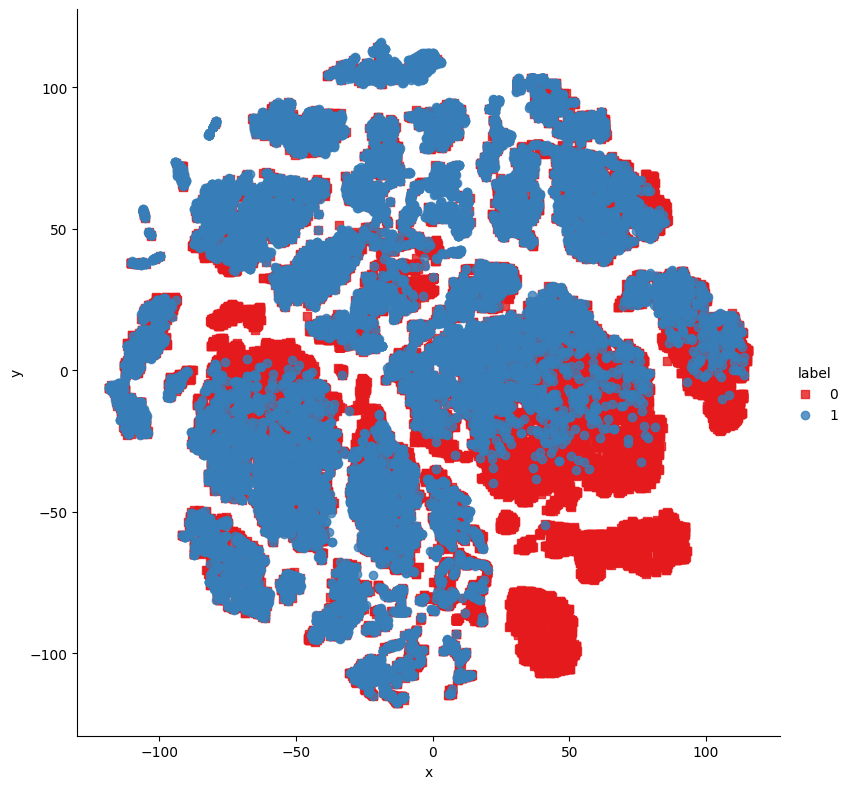

In [122]:
x_df = pd.DataFrame({"x": tsne2d[:,0], "y": tsne2d[:,1], "label":y})
sns.lmplot(data= x_df, x= "x", y="y", fit_reg= False,hue= "label", height=8, palette="Set1",markers=['s','o'],)

In [123]:
from sklearn.manifold import TSNE

tsne3d = TSNE(
    n_components=3,
    init="random",
    random_state=10,
    method="barnes_hut",
    max_iter=1000,   # ✅ fixed
    verbose=2,
    angle=0.5
).fit_transform(x)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.149s...
[t-SNE] Computed neighbors for 50000 samples in 10.064s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sa

In [124]:
# pip install nbformat
# !pip install -U nbformat ipython

In [125]:
# x_df = pd.DataFrame({
#     "x": tsne3d[:, 0],
#     "y": tsne3d[:, 1],
#     "z": tsne3d[:, 2],  # Third dimension from another feature
#     "label": y
# })

# # Create the 3D plot using Plotly Express
# fig = px.scatter_3d(
#     x_df,
#     x="x",
#     y="y",
#     z="z",
#     color="label",
#     symbol="label",
#     title='3D t-SNE Visualization',
#     labels={'x': 't-SNE feature 1', 'y': 't-SNE feature 2', 'z': 't-SNE feature 3'},
#     color_discrete_sequence=px.colors.qualitative.Set1,
#     symbol_sequence=['circle', 'square', 'diamond', 'x']
# )

# # Show the plot
# plt.figure(figsize= (6,4))
# fig.show()


import plotly.express as px
import pandas as pd

x_df = pd.DataFrame({
    "x": tsne3d[:, 0],
    "y": tsne3d[:, 1],
    "z": tsne3d[:, 2],
    "label": y
})

fig = px.scatter_3d(
    x_df,
    x="x",
    y="y",
    z="z",
    color="label",
    symbol="label",
    title='3D t-SNE Visualization'
)

fig.show(renderer="browser")  # ✅ safe for all env

In [126]:
# import plotly.graph_objs as go
# import plotly.tools as tls
# import plotly.offline as py
# py.init_notebook_mode(connected=True)

# trace1 = go.Scatter3d(
#     x=tsne3d[:,0],
#     y=tsne3d[:,1],
#     z=tsne3d[:,2],
#     mode='markers',
#     marker=dict(
#         sizemode='diameter',
#         color = y,
#         colorscale = 'Portland',
#         colorbar = dict(title = 'duplicate'),
#         line=dict(color='rgb(255, 255, 255)'),
#         opacity=0.75
#     )
# )

# data=[trace1]
# layout=dict(height=800, width=800, title='3d embedding with engineered features')
# fig=dict(data=data, layout=layout)
# py.iplot(fig, filename='3DBubble')

In [127]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
339499,339499,665522,665523,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri,1,51,36,11,8,...,0.545450,0.0,1.0,3.0,9.5,0.324324,39,47,67,88
289521,289521,568878,568879,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...,0,49,99,11,24,...,0.136363,0.0,0.0,11.0,16.5,0.120000,26,49,38,39
4665,4665,9325,9326,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...,0,127,127,59,59,...,0.749997,1.0,1.0,0.0,24.0,0.992188,100,100,100,100
54203,54203,107861,107862,whi do quora mark my question a incomplet,whi doe quora detect my question a an incomple...,1,41,55,8,10,...,0.599994,0.0,1.0,2.0,9.0,0.357143,77,76,75,89
132566,132566,262554,91499,what be it like work with pivot lab a a client,what be it like to work at pivot lab,0,46,36,11,9,...,0.636358,0.0,1.0,2.0,10.0,0.432432,78,89,78,91


In [128]:

ques_df = df[['question1','question2']]
ques_df.head()

,question1,question2
339499,whi wa cyru mistri remov a the chairman of tat...,whi do the tata son sack cyru mistri
289521,by what age would you think a man should be marri,when my wrist be extend i feel a shock and bur...
4665,how would an arbitrageur seek to capit give th...,how would an arbitrageur seek to capit give th...
54203,whi do quora mark my question a incomplet,whi doe quora detect my question a an incomple...
132566,what be it like work with pivot lab a a client,what be it like to work at pivot lab


In [129]:

final_df = df.drop(columns=['id','qid1','qid2','question1','question2'])
print(final_df.shape)
final_df.head()

(50000, 23)


,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,word_common,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,fuzz_token_sort_ratio,fuzz_token_set_ratio
339499,1,51,36,11,8,6,19,0.32,0.833319,0.624992,...,0.545450,0.0,1.0,3.0,9.5,0.324324,39,47,67,88
289521,0,49,99,11,24,3,31,0.10,0.000000,0.000000,...,0.136363,0.0,0.0,11.0,16.5,0.120000,26,49,38,39
4665,0,127,127,59,59,19,38,0.50,0.999992,0.999992,...,0.749997,1.0,1.0,0.0,24.0,0.992188,100,100,100,100
54203,1,41,55,8,10,6,18,0.33,0.799984,0.571420,...,0.599994,0.0,1.0,2.0,9.0,0.357143,77,76,75,89
132566,0,46,36,11,9,7,19,0.37,0.999975,0.799984,...,0.636358,0.0,1.0,2.0,10.0,0.432432,78,89,78,91


In [130]:
from sklearn.feature_extraction.text import CountVectorizer
questions = list(ques_df["question1"])+ list(ques_df["question2"])
cvt = CountVectorizer(max_features= 5000)
q1_arr, q2_arr = np.vsplit(cvt.fit_transform(questions).toarray(),2)

In [131]:
temp_df1 = pd.DataFrame(q1_arr, index = ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index = ques_df.index)
new_df= pd.concat([temp_df1,temp_df2], axis=1)
new_df.shape

(50000, 10000)

In [133]:
# final_df = pd.concat([final_df, new_df], axis= 1)
# print(final_df.shape)

In [136]:
final_df = pd.concat([final_df, new_df], axis=1, copy=False)

In [137]:
final_df.head()

,is_duplicate,q1_len,q2_len,q1_num_word,q2_num_word,word_common,word_total,word_share,cwc_min,cwc_max,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
339499,1,51,36,11,8,6,19,0.32,0.833319,0.624992,...,0,0,0,0,0,0,0,0,0,0
289521,0,49,99,11,24,3,31,0.10,0.000000,0.000000,...,0,0,0,0,0,0,0,0,0,0
4665,0,127,127,59,59,19,38,0.50,0.999992,0.999992,...,0,0,0,0,0,0,0,0,0,0
54203,1,41,55,8,10,6,18,0.33,0.799984,0.571420,...,0,0,0,0,0,0,0,0,0,0
132566,0,46,36,11,9,7,19,0.37,0.999975,0.799984,...,0,0,0,0,0,0,0,0,0,0


In [138]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(final_df.iloc[:,1:].values,final_df.iloc[:,0].values,test_size=0.2,random_state=1)

MemoryError: Unable to allocate 3.73 GiB for an array with shape (10022, 50000) and data type float64

In [142]:
import numpy as np
import gc

# Save y
y = final_df.iloc[:, 0].values
np.save('y.npy', y)
del y
gc.collect()

# Save X column by column to memmap
n_rows = final_df.shape[0]
n_cols = final_df.shape[1] - 1

X_map = np.memmap('X.dat', dtype='float32', mode='w+', shape=(n_rows, n_cols))

chunk = 1000
for i in range(0, n_cols, chunk):
    print(f"Writing cols {i} to {min(i+chunk, n_cols)}...")
    X_map[:, i:i+chunk] = final_df.iloc[:, i+1:i+1+chunk].values.astype(np.float32)
    gc.collect()

del X_map
del final_df  # FREE the original df
gc.collect()

# Reload as memmap (reads from disk, not RAM)
X = np.memmap('X.dat', dtype='float32', mode='r', shape=(n_rows, n_cols))
y = np.load('y.npy')

train_idx, test_idx = train_test_split(np.arange(n_rows), test_size=0.2, random_state=1)

xtrain, xtest = X[train_idx], X[test_idx]
ytrain, ytest = y[train_idx], y[test_idx]

print(f"xtrain: {xtrain.shape}, xtest: {xtest.shape}")

Writing cols 0 to 1000...
Writing cols 1000 to 2000...
Writing cols 2000 to 3000...
Writing cols 3000 to 4000...
Writing cols 4000 to 5000...
Writing cols 5000 to 6000...
Writing cols 6000 to 7000...
Writing cols 7000 to 8000...
Writing cols 8000 to 9000...
Writing cols 9000 to 10000...
Writing cols 10000 to 10022...
xtrain: (40000, 10022), xtest: (10000, 10022)


In [143]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier()
rf.fit(xtrain,ytrain)
rf.score(xtest,ytest)

0.801

In [144]:
ypred = rf.predict(xtest)
accuracy_score(ytest,ypred)

0.801

In [145]:

from xgboost import XGBClassifier
xgb = XGBClassifier()
model = xgb.fit(xtrain,ytrain)
y_pred1 = xgb.predict(xtest)
accuracy_score(ytest,y_pred1)

0.799

# confusion Matrix

In [146]:
from sklearn.metrics import confusion_matrix

In [147]:
# for random forest model
cm = confusion_matrix(ytest,ypred)

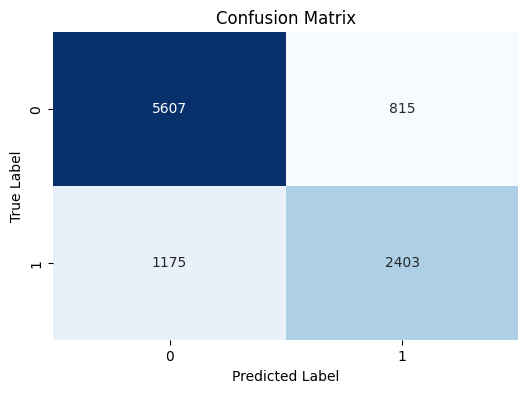

In [148]:
# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [149]:
# for xgboost model
cm = confusion_matrix(ytest,y_pred1)

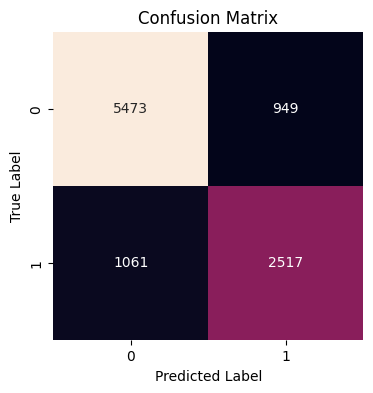

In [150]:
plt.figure(figsize= (4,4))
sns.heatmap(cm, annot= True,fmt='d', cbar=False )
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# test model with new data 

In [151]:
q1 = 'Where is the capital of India?'
q2 = 'What is the current capital of Pakistan?'
q3 = 'Which city serves as the capital of India?'
q4 = 'Where is the capital of India?'

In [152]:

def test_common_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return len(w1 & w2)

In [153]:

def test_total_words(q1,q2):
    w1 = set(map(lambda word: word.lower().strip(), q1.split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), q2.split(" ")))    
    return (len(w1) + len(w2))

In [154]:
def test_fetch_token_features(q1,q2):
    
    SAFE_DIV = 0.0001 

    STOP_WORDS = stopwords.words("english")
    
    token_features = [0.0]*8
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])
    
    #Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])
    
    # Get the common non-stopwords from Question pair
    common_word_count = len(q1_words.intersection(q2_words))
    # Get the common stopwords from Question pair
    common_stop_count = len(q1_stops.intersection(q2_stops))
    
    # Get the common Tokens from Question pair
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))
    
    
    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    
    # Last word of both question is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
    
    # First word of both question is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])
    
    return token_features

In [155]:
def test_fetch_length_features(q1,q2):
    
    length_features = [0.0]*3
    
    # Converting the Sentence into Tokens: 
    q1_tokens = q1.split()
    q2_tokens = q2.split()
    
    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features
    
    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
    
    #Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens))/2
    
    strs = list(distance.lcsubstrings(q1, q2))
    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)
    
    return length_features

In [156]:
def test_fetch_fuzzy_features(q1,q2):
    
    fuzzy_features = [0.0]*4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)

    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)

    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)

    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)

    return fuzzy_features

In [157]:
def query_point_creator(q1,q2):
    
    input_query = []
    
    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)
    
    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))
    
    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))
    
    input_query.append(test_common_words(q1,q2))
    input_query.append(test_total_words(q1,q2))
    input_query.append(round(test_common_words(q1,q2)/test_total_words(q1,q2),2))
    
    # fetch token features
    token_features = test_fetch_token_features(q1,q2)
    input_query.extend(token_features)
    
    # fetch length based features
    length_features = test_fetch_length_features(q1,q2)
    input_query.extend(length_features)
     # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1,q2)
    input_query.extend(fuzzy_features)
    
    # bow feature for q1
    q1_bow = cvt.transform([q1]).toarray()
    
    # bow feature for q2
    q2_bow = cvt.transform([q2]).toarray()
    
    
    
    return np.hstack((np.array(input_query).reshape(1,22),q1_bow,q2_bow))

In [158]:

rf.predict(query_point_creator(q1,q4))

array([1], dtype=int8)

In [161]:

import pickle

with open('Rf_with_test.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('xgb_with_test.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('cv.pkl', 'wb') as f:
    pickle.dump(cvt, f)

In [162]:
cvt

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"
,analyzer,'word'
